# 02 — Network Construction
## TeleShift: Seasonal Comparison of Extreme Precipitation Synchronization Networks

This notebook constructs two directed weighted climate networks from ERA5 reanalysis
data — one for boreal winter (DJF: December–January–February) and one for boreal
summer (JJA: June–July–August).

### Runtime environment

This notebook is designed to run on **Google Colab Pro with A100 GPU**. The core
computation — Directional Event Synchronization across ~58 million node pairs —
is accelerated using CuPy, a GPU-native drop-in replacement for NumPy. On a
standard CPU this computation would take 2–4 hours; on an A100 GPU it completes
in approximately 5–15 minutes.

All outputs are saved to Google Drive and downloaded to the local machine for
subsequent analysis in `03_analysis.ipynb`.

### What is a climate network?

A climate network represents statistical relationships between geographic locations.
Each **node** is a grid cell on Earth's surface. A directed **edge** from node i
to node j means that extreme precipitation events at location i tend to **precede**
extreme events at location j within a dynamic time window — a genuine lagged
teleconnection relationship.

### Methodological approach — why Event Synchronization?

Several synchronization methods were evaluated during development:

| Method | Direction | Lag | Binary data | Feasible at scale | Chosen |
|---|---|---|---|---|---|
| Pearson correlation | No | No | Suboptimal | Yes | No |
| Linear Granger Causality | Yes | Yes | Suboptimal | Partially | No |
| Logistic Granger Causality | Yes | Yes | Yes | No | No |
| **Directional Event Synchronization** | **Yes** | **Yes** | **Yes** | **Yes** | **Yes** |

**Pearson correlation** was tested first and found to produce networks completely
dominated by short-range spatial autocorrelation — at both 1° and 2° resolution,
applying a 500 km minimum distance mask removed over 99% of all edges, confirming
that surviving links were local artifacts rather than genuine teleconnections.

**Logistic Granger Causality** was proposed as a more rigorous directional method
appropriate for binary event series. However at 10,800 nodes (58 million directed
pairs × 417 sliding windows) the computation is infeasible even with GPU acceleration
due to the per-pair model fitting overhead.

**Directional Event Synchronization (ES)** is the de facto standard for extreme
precipitation climate networks (Quiroga et al. 2002, Malik et al. 2012, Boers et al.
2014). It is specifically designed for binary event series, captures lagged
directional relationships through a dynamic time window, and is fully vectorisable
for GPU execution. It directly addresses the directionality and lag concerns raised
during methodology review.

### Analysis domain

The analysis is restricted to **60°S – 60°N**. Polar regions are excluded because
at 2° resolution polar grid cells are physically tiny (~7 km wide at 88°S), producing
trivially high same-day correlations. Testing confirmed that 100% of hubs in unmasked
networks were located in polar regions — a physically implausible result.

### What this notebook produces

| Output | Description |
|---|---|
| `es_DJF.npy` | Directional ES score matrix (n_nodes × n_nodes), winter |
| `es_JJA.npy` | Directional ES score matrix (n_nodes × n_nodes), summer |
| `es_threshold_DJF.npy` | Surrogate-based significance threshold, winter |
| `es_threshold_JJA.npy` | Surrogate-based significance threshold, summer |
| `network_DJF.gexf` | Directed NetworkX graph for Gephi, winter |
| `network_JJA.gexf` | Directed NetworkX graph for Gephi, summer |
| `nodes_DJF.csv` | Node attributes (lat, lon, in-degree, out-degree), winter |
| `nodes_JJA.csv` | Node attributes (lat, lon, in-degree, out-degree), summer |

### Pipeline position

`01_data_collection` → **`02_network_construction`** → `03_analysis` → `04_visualization`

### Steps in this notebook

1. GPU setup & libraries
2. Drive mount & paths
3. Data loading & inspection
4. Regridding to 2° & polar masking
5. Season splitting
6. Extreme event definition
7. Directional Event Synchronization (GPU)
8. Surrogate-based significance thresholding
9. NetworkX graph construction
10. Export & download

## 1. GPU Setup & Libraries

### Why A100 GPU?

The ES matrix computation requires evaluating ~58 million directed node pairs.
For each pair we compute a matrix of pairwise event time differences and apply
dynamic lag window masking — operations that are embarrassingly parallel and
map directly onto GPU architecture.

The NVIDIA A100 provides:
- **6,912 CUDA cores** for massively parallel floating-point operations
- **40–80 GB HBM2e memory** — fits all intermediate arrays simultaneously
- **~312 TFLOPS** FP32 throughput

We use **CuPy** — a drop-in NumPy replacement for CUDA GPUs. Array operations
written with `cp.*` instead of `np.*` execute on the GPU with no algorithmic
changes required. Results are transferred back to CPU as standard NumPy arrays
for saving and export.

In [1]:
# ── Install CuPy (CUDA 12.x for Colab A100/V100) ────────────────────────────
!pip install cupy-cuda12x -q
!pip install cartopy

import cupy as cp
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import networkx as nx
from tqdm import tqdm
import os

# ── Verify GPU ────────────────────────────────────────────────────────────────
device = cp.cuda.Device()
mem_total = device.mem_info[1] / 1e9
mem_free  = device.mem_info[0] / 1e9
# GPU adını runtime özelliklerinden alalım:
gpu_name = cp.cuda.runtime.getDeviceProperties(device.id)['name'].decode('utf-8')

print(f'GPU device     : {gpu_name}')
print(f'Total memory   : {mem_total:.1f} GB')
print(f'Free memory    : {mem_free:.1f} GB')
print(f'CuPy version   : {cp.__version__}')
print(f'NumPy version  : {np.__version__}')
print()
print('All libraries loaded successfully.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 77.4 MB/s eta 0:00:00
GPU device     : NVIDIA A100-SXM4-80GB
Total memory   : 85.1 GB
Free memory    : 84.6 GB
CuPy version   : 14.0.1
NumPy version  : 2.0.2

All libraries loaded successfully.


## 2. Drive Mount & Paths

We mount Google Drive to access the ERA5 raw data files uploaded before
running this notebook. All outputs are also saved to Drive so they persist
after the Colab session ends.

### Files required in Drive

Before running this notebook, the following files must be uploaded to
`My Drive/TeleShift/raw/`:

```
era5_precip_1980_2026_DJF_JJA_1deg_contiguous.nc
era5_z500_1980_2026_DJF_JJA_1deg_contiguous.nc
```

Output directories are created automatically if they don't exist.

In [2]:
# ── Mount Google Drive ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_RAW = '/content/drive/MyDrive/TeleShift/raw'
DATA_OUT = '/content/drive/MyDrive/TeleShift/outputs'
FIG_OUT  = '/content/drive/MyDrive/TeleShift/figures'

PRECIP_FILE = os.path.join(DATA_RAW, 'era5_precip_1980_2026_DJF_JJA_1deg_contiguous.nc')
Z500_FILE   = os.path.join(DATA_RAW, 'era5_z500_1980_2026_DJF_JJA_1deg_contiguous.nc')

os.makedirs(DATA_OUT, exist_ok=True)
os.makedirs(FIG_OUT,  exist_ok=True)

# ── Verify files exist ────────────────────────────────────────────────────────
for f, label in [(PRECIP_FILE, 'Precip'), (Z500_FILE, 'Z500')]:
    exists = os.path.exists(f)
    size   = os.path.getsize(f) / 1e9 if exists else 0
    status = f'OK ({size:.2f} GB)' if exists else 'NOT FOUND'
    print(f'{label:8s}: {status}')
    if not exists:
        print(f'          Expected at: {f}')

Mounted at /content/drive
Precip  : OK (2.19 GB)
Z500    : OK (2.19 GB)


## 3. Data Loading & Inspection

Both files were prepared in `01_data_collection.ipynb`:
- Regridded to **1° spatial resolution** (180 lat × 360 lon = 64,800 cells)
- Filtered to **DJF and JJA timesteps only** (1980–2026)
- Saved as contiguous unchunked NetCDF for fast array access

The 1° files are our **master source files** — all spatial processing
happens in memory and the originals remain untouched on Drive.

### Key dimensions

| Dimension | Description | Expected |
|---|---|---|
| `latitude` | Grid cell latitude | 180 steps |
| `longitude` | Grid cell longitude | 360 steps |
| `valid_time` | One entry per day, DJF + JJA only | ~4,200 timesteps |

### Variables

| File | Variable | Description |
|---|---|---|
| Precip | `tp` | Total precipitation (m/day) |
| Z500 | `z` | 500 hPa geopotential height (m²/s²) |

In [3]:
ds_precip = xr.open_dataset(PRECIP_FILE)
ds_z500   = xr.open_dataset(Z500_FILE)

lat  = ds_precip['latitude'].values
lon  = ds_precip['longitude'].values
time = ds_precip['valid_time'].values

print('=' * 55)
print('PRECIPITATION DATASET')
print('=' * 55)
print(f'Shape     : {ds_precip["tp"].shape}')
print(f'Latitude  : {lat.min():.2f}° to {lat.max():.2f}°  |  {len(lat)} steps')
print(f'Longitude : {lon.min():.2f}° to {lon.max():.2f}°  |  {len(lon)} steps')
print(f'Time steps: {len(time)}')
print(f'Date range: {str(time[0])[:10]}  →  {str(time[-1])[:10]}')
print()
print('=' * 55)
print('Z500 DATASET')
print('=' * 55)
print(f'Shape     : {ds_z500["z"].shape}')
print(f'           (size-1 pressure_level dimension squeezed out in Section 4)')
print()

assert len(lat) == 180, f'Expected 180 lat steps, got {len(lat)}'
assert len(lon) == 360, f'Expected 360 lon steps, got {len(lon)}'
assert 8000 < len(time) < 9000, f'Unexpected timestep count: {len(time)}'
print('All dimension checks passed.')

PRECIPITATION DATASET
Shape     : (8443, 180, 360)
Latitude  : -89.38° to 89.62°  |  180 steps
Longitude : 0.38° to 359.38°  |  360 steps
Time steps: 8443
Date range: 1980-01-01  →  2026-02-28

Z500 DATASET
Shape     : (8443, 1, 180, 360)
           (size-1 pressure_level dimension squeezed out in Section 4)

All dimension checks passed.


## 4. Regridding to 2° & Polar Masking

These two preprocessing steps address the same core problem:
**spurious correlations masking genuine teleconnection signals**.

### 4.1 Regridding to 2°

At 1° resolution, neighbouring grid cells are ~100 km apart. Precipitation
fields are spatially smooth — a single storm system covering 500 km produces
high correlations across ~5 adjacent cells. During development, testing on 1°
networks showed that a 500 km minimum distance mask removed **99.99% of all
edges**, confirming that virtually all surviving links were local autocorrelation
artifacts.

At 2° resolution, neighbouring cells are ~220 km apart — reducing the local
autocorrelation problem while keeping the correlation matrix at ~450 MB
(manageable on GPU).

| Resolution | Nodes | ES matrix size | Node pairs |
|---|---|---|---|
| 1° | 64,800 | ~33 GB | 4.2 billion |
| 2° | 16,200 | ~2 GB | 131 million |
| 2° + polar mask | ~10,800 | ~450 MB | ~58 million |

### 4.2 Polar masking (60°S – 60°N)

Even at 2°, polar grid cells remain problematic. At 88°S a 2° cell is only
~7 km wide — neighbouring cells measure essentially the same local weather.
Testing on unmasked 2° networks confirmed that **100% of identified hubs
were in polar regions** — a physically implausible result.

We restrict to **60°S – 60°N**, retaining all climatologically relevant regions:
tropics, ITCZ, all major monsoon systems, midlatitude storm tracks, and
Rossby wave corridors. This domain restriction is consistent with the literature
— Boers et al. 2014 focused on 30°S–30°N; Scarsoglio et al. 2013 applied
similar polar cutoffs.

Note: ES is less sensitive to the polar artifact than Pearson correlation
because it tests for **lagged** relationships rather than instantaneous
co-occurrence. However the polar exclusion is maintained for physical
interpretability and comparison with the literature.

In [4]:
# ── Coarsen from 1° to 2° ─────────────────────────────────────────────────────
# coarsen() aggregates 2×2 blocks of 1° cells using the mean —
# giving area-averaged values. boundary='trim' drops edge cells
# that don't fit cleanly, producing a perfectly regular 2° grid.

COARSEN_FACTOR = 2

print('Coarsening precipitation dataset to 2°...')
ds_precip_2deg = ds_precip.coarsen(
    latitude=COARSEN_FACTOR,
    longitude=COARSEN_FACTOR,
    boundary='trim'
).mean()

print('Coarsening Z500 dataset to 2°...')
ds_z500_2deg = ds_z500.coarsen(
    latitude=COARSEN_FACTOR,
    longitude=COARSEN_FACTOR,
    boundary='trim'
).mean()

print(f'Precip shape after coarsening : {ds_precip_2deg["tp"].shape}')
print(f'Z500 shape after coarsening   : {ds_z500_2deg["z"].shape}')
print()

# ── Apply polar mask (60°S – 60°N) ────────────────────────────────────────────
LAT_MIN = -60.0
LAT_MAX =  60.0

lat_2deg = ds_precip_2deg['latitude'].values
lon      = ds_precip_2deg['longitude'].values

ds_precip_masked = ds_precip_2deg.sel(
    latitude=lat_2deg[(lat_2deg >= LAT_MIN) & (lat_2deg <= LAT_MAX)]
)
ds_z500_masked = ds_z500_2deg.sel(
    latitude=lat_2deg[(lat_2deg >= LAT_MIN) & (lat_2deg <= LAT_MAX)]
)

# ERA5 pressure-level variables include a size-1 level dimension —
# squeeze it out so Z500 shape matches (time, lat, lon)
ds_z500_masked = ds_z500_masked.squeeze('pressure_level')

# Update lat array to masked domain
lat = ds_precip_masked['latitude'].values

print(f'Polar mask applied : {LAT_MIN}° to {LAT_MAX}°')
print(f'Latitude  : {lat.min():.2f}° to {lat.max():.2f}°  |  {len(lat)} steps')
print(f'Longitude : {lon.min():.2f}° to {lon.max():.2f}°  |  {len(lon)} steps')
print(f'Total nodes in analysis domain : {len(lat) * len(lon):,}')
print()
print(f'Precip shape : {ds_precip_masked["tp"].shape}')
print(f'Z500 shape   : {ds_z500_masked["z"].shape}')

Coarsening precipitation dataset to 2°...
Coarsening Z500 dataset to 2°...
Precip shape after coarsening : (8443, 90, 180)
Z500 shape after coarsening   : (8443, 1, 90, 180)

Polar mask applied : -60.0° to 60.0°
Latitude  : -58.88° to 59.12°  |  60 steps
Longitude : 0.88° to 358.88°  |  180 steps
Total nodes in analysis domain : 10,800

Precip shape : (8443, 60, 180)
Z500 shape   : (8443, 60, 180)


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


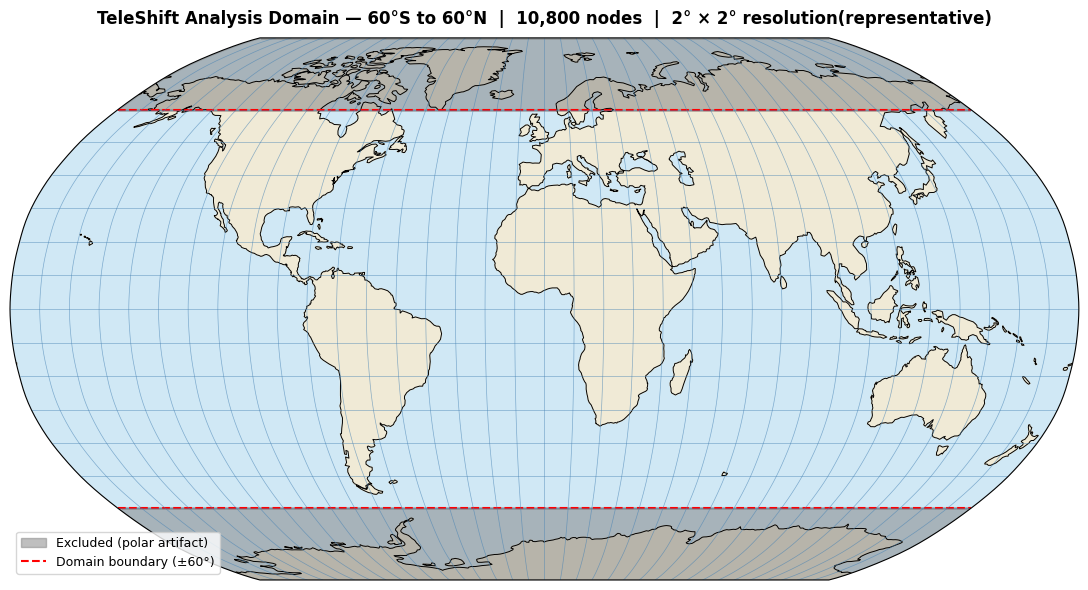

Figure saved → figures/analysis_domain.png


In [5]:
# ── Visualize analysis domain ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6),
                       subplot_kw={'projection': ccrs.Robinson()})

ax.set_global()
ax.add_feature(cfeature.OCEAN,     color='#d0e8f5')
ax.add_feature(cfeature.LAND,      color='#f0ead6')
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)

# Shade excluded polar regions
ax.fill_between([-180, 180], [60, 60], [90, 90],
                transform=ccrs.PlateCarree(),
                color='grey', alpha=0.5, label='Excluded (polar artifact)')
ax.fill_between([-180, 180], [-90, -90], [-60, -60],
                transform=ccrs.PlateCarree(), color='grey', alpha=0.5)

# Domain boundary lines
ax.plot([-180, 180], [60, 60],
        transform=ccrs.PlateCarree(),
        color='red', linewidth=1.5, linestyle='--')
ax.plot([-180, 180], [-60, -60],
        transform=ccrs.PlateCarree(),
        color='red', linewidth=1.5, linestyle='--',
        label='Domain boundary (±60°)')

ax.gridlines(crs=ccrs.PlateCarree(),
             xlocs=np.arange(-180, 181, 10),
             ylocs=np.arange(-60,   61, 10),
             draw_labels=False,
             linewidth=0.5, color='steelblue', alpha=0.6)

ax.set_title(f'TeleShift Analysis Domain — 60°S to 60°N  |  '
             f'{len(lat) * len(lon):,} nodes  |  2° × 2° resolution(representative)',
             fontsize=12, fontweight='bold', pad=10)
ax.legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_OUT, 'analysis_domain.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → figures/analysis_domain.png')

## 5. Season Splitting

We split the masked data into DJF and JJA subsets by checking the month
of each `valid_time` entry.

### Why DJF and JJA?

| Season | Months | Code | Physical rationale |
|---|---|---|---|
| Boreal winter | December, January, February | DJF | NH jet stream and Rossby wave activity peaks |
| Boreal summer | June, July, August | JJA | Tropical monsoon systems dominate global precipitation |

These two seasons represent the most dynamically distinct states of the
global atmosphere — the ideal pair for seasonal teleconnection comparison.

Both ERA5 files were pre-filtered in `01_data_collection.ipynb` to contain
only DJF and JJA timesteps. We verify this explicitly before splitting.

In [6]:
# ── Verify months present ─────────────────────────────────────────────────────
months        = ds_precip_masked['valid_time'].dt.month.values
unique_months = np.unique(months)

print(f'Months present : {unique_months}')
print(f'Expected       : [1 2 6 7 8 12]')

unexpected = set(unique_months) - {1, 2, 6, 7, 8, 12}
if unexpected:
    raise ValueError(f'Unexpected months found: {unexpected}. '
                     f'Revisit 01_data_collection.ipynb.')
else:
    print('OK — only DJF and JJA months present.')

Months present : [ 1  2  6  7  8 12]
Expected       : [1 2 6 7 8 12]
OK — only DJF and JJA months present.


In [7]:
# ── Create season masks and split data ───────────────────────────────────────
mask_DJF = np.isin(months, [12, 1, 2])
mask_JJA = np.isin(months, [6, 7, 8])

# Precipitation — (n_timesteps, lat, lon)
precip_DJF = ds_precip_masked['tp'].values[mask_DJF]
precip_JJA = ds_precip_masked['tp'].values[mask_JJA]

# Z500 — size-1 level dimension already squeezed in Section 4
z500_DJF = ds_z500_masked['z'].values[mask_DJF]
z500_JJA = ds_z500_masked['z'].values[mask_JJA]

print(f'DJF timesteps : {precip_DJF.shape[0]}')
print(f'JJA timesteps : {precip_JJA.shape[0]}')
print()
print(f'precip_DJF shape : {precip_DJF.shape}')
print(f'precip_JJA shape : {precip_JJA.shape}')
print(f'z500_DJF shape   : {z500_DJF.shape}')
print(f'z500_JJA shape   : {z500_JJA.shape}')
print()

# DJF timesteps slightly less than JJA — expected, December 1979 absent
# since record starts January 1980
assert abs(precip_DJF.shape[0] - precip_JJA.shape[0]) < 100,     'Unexpected large difference in season lengths'
print('Season length check passed.')

DJF timesteps : 4211
JJA timesteps : 4232

precip_DJF shape : (4211, 60, 180)
precip_JJA shape : (4232, 60, 180)
z500_DJF shape   : (4211, 60, 180)
z500_JJA shape   : (4232, 60, 180)

Season length check passed.


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


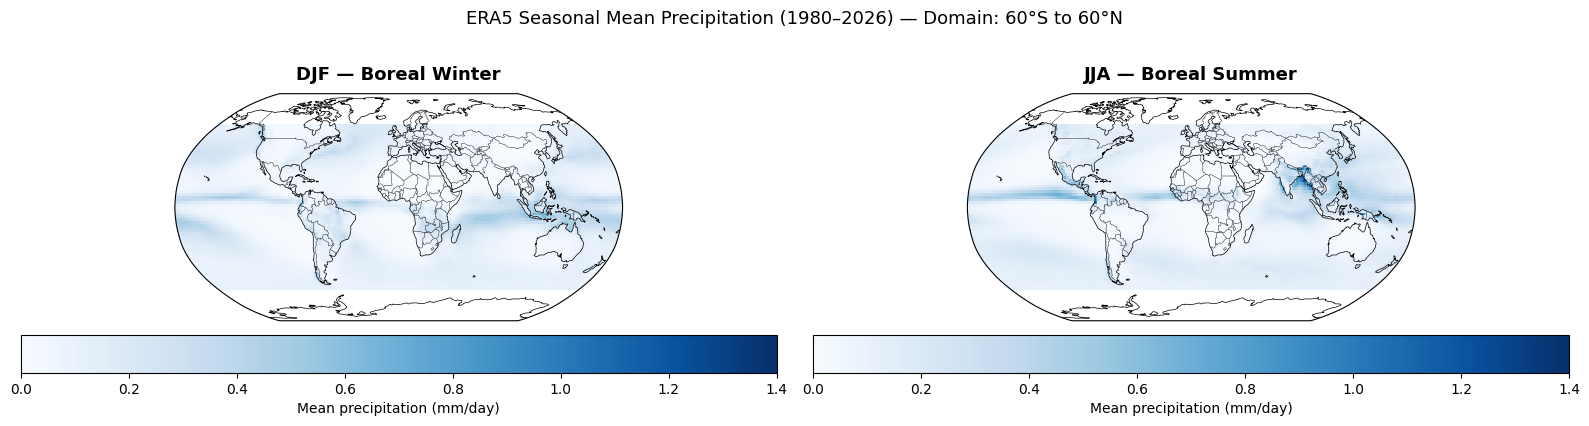

Figure saved → figures/seasonal_mean_precip.png


In [8]:
# ── Seasonal mean precipitation maps ──────────────────────────────────────────
# Sanity check — confirms season split worked and gives first visual
# of the data within the analysis domain.
# Shared colorscale vmax=1.4 makes the JJA monsoon excess visible.

fig, axes = plt.subplots(1, 2, figsize=(16, 4),
                         subplot_kw={'projection': ccrs.Robinson()})

for ax, data, title in zip(axes,
                           [precip_DJF, precip_JJA],
                           ['DJF — Boreal Winter', 'JJA — Boreal Summer']):
    mean_map = np.mean(data, axis=0) * 1000  # m/day → mm/day

    ax.set_global()
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3)

    im = ax.pcolormesh(lon, lat, mean_map,
                       transform=ccrs.PlateCarree(),
                       cmap='Blues', shading='auto',
                       vmin=0, vmax=1.4)

    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    plt.colorbar(im, ax=ax, orientation='horizontal',
                 pad=0.05, label='Mean precipitation (mm/day)')

plt.suptitle('ERA5 Seasonal Mean Precipitation (1980–2026) — Domain: 60°S to 60°N',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_OUT, 'seasonal_mean_precip.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → figures/seasonal_mean_precip.png')

## 6. Extreme Event Definition

### Why binary extreme event series?

We work with binary extreme event series rather than raw precipitation
values or continuous anomalies for the following reasons:

- Raw precipitation is highly non-normal and zero-inflated
- Continuous anomalies retain magnitude information but for teleconnection
  analysis we care about the **occurrence** of anomalous events
- Binary series encode the physically meaningful question:
  *"Was today unusually wet for this location?"*
- Event Synchronization is specifically designed for binary event series —
  the binary representation is the natural input

### Local percentile thresholding

For each grid cell independently we compute the **90th percentile** of its
precipitation distribution across all season timesteps and binarize:

    event(t) = 1  if precip(t) > p90
    event(t) = 0  otherwise

By construction exactly **10% of timesteps** at each grid cell are flagged
as extreme — making cross-location comparisons meaningful regardless of
whether the location is a tropical rainforest or a semi-arid region.

### Why 90th percentile?

Each grid cell has ~420 extreme days per season (10% of ~4,200 timesteps).
This gives ES sufficient event density for stable co-occurrence statistics.
Higher thresholds (95th, 99th) produce too few events; lower thresholds
(80th) blur the distinction between normal and extreme conditions.

In [9]:
# ── Compute binary extreme event series ───────────────────────────────────────
# np.percentile with axis=0 computes one threshold per grid cell
# by looking across all timesteps — result shape: (lat, lon)
# NumPy broadcasts p90 across the time dimension automatically

THRESHOLD_PERCENTILE = 90

print('Computing extreme event binary series...')

p90_DJF     = np.percentile(precip_DJF, THRESHOLD_PERCENTILE, axis=0)
extreme_DJF = (precip_DJF > p90_DJF).astype(np.uint8)

p90_JJA     = np.percentile(precip_JJA, THRESHOLD_PERCENTILE, axis=0)
extreme_JJA = (precip_JJA > p90_JJA).astype(np.uint8)

print('Done.')
print()
print(f'extreme_DJF shape : {extreme_DJF.shape}  |  dtype: {extreme_DJF.dtype}')
print(f'extreme_JJA shape : {extreme_JJA.shape}  |  dtype: {extreme_JJA.dtype}')
print()

# mean() on binary array = fraction of 1s = flagging rate
# Should be ~0.10 everywhere by construction
print(f'Mean flagging rate DJF : {extreme_DJF.mean():.3f}  (expected ~0.100)')
print(f'Mean flagging rate JJA : {extreme_JJA.mean():.3f}  (expected ~0.100)')

Computing extreme event binary series...
Done.

extreme_DJF shape : (4211, 60, 180)  |  dtype: uint8
extreme_JJA shape : (4232, 60, 180)  |  dtype: uint8

Mean flagging rate DJF : 0.098  (expected ~0.100)
Mean flagging rate JJA : 0.098  (expected ~0.100)


In [10]:
# ── Reshape to (time, n_nodes) ────────────────────────────────────────────────
# Flatten (lat, lon) into a single node axis.
# Node index maps back to coordinates as:
#   lat_idx = node_idx // n_lon  (integer division)
#   lon_idx = node_idx  % n_lon  (remainder)
# This works because NumPy flattens in row-major (C) order —
# longitude is the fast-moving dimension.

n_lat, n_lon = len(lat), len(lon)
n_nodes      = n_lat * n_lon

ex_DJF_flat = extreme_DJF.reshape(-1, n_nodes)  # (n_DJF, n_nodes)
ex_JJA_flat = extreme_JJA.reshape(-1, n_nodes)  # (n_JJA, n_nodes)

print(f'n_nodes           : {n_nodes:,}')
print(f'ex_DJF_flat shape : {ex_DJF_flat.shape}')
print(f'ex_JJA_flat shape : {ex_JJA_flat.shape}')
print(f'Memory (DJF)      : {ex_DJF_flat.nbytes / 1e6:.1f} MB')

n_nodes           : 10,800
ex_DJF_flat shape : (4211, 10800)
ex_JJA_flat shape : (4232, 10800)
Memory (DJF)      : 45.5 MB


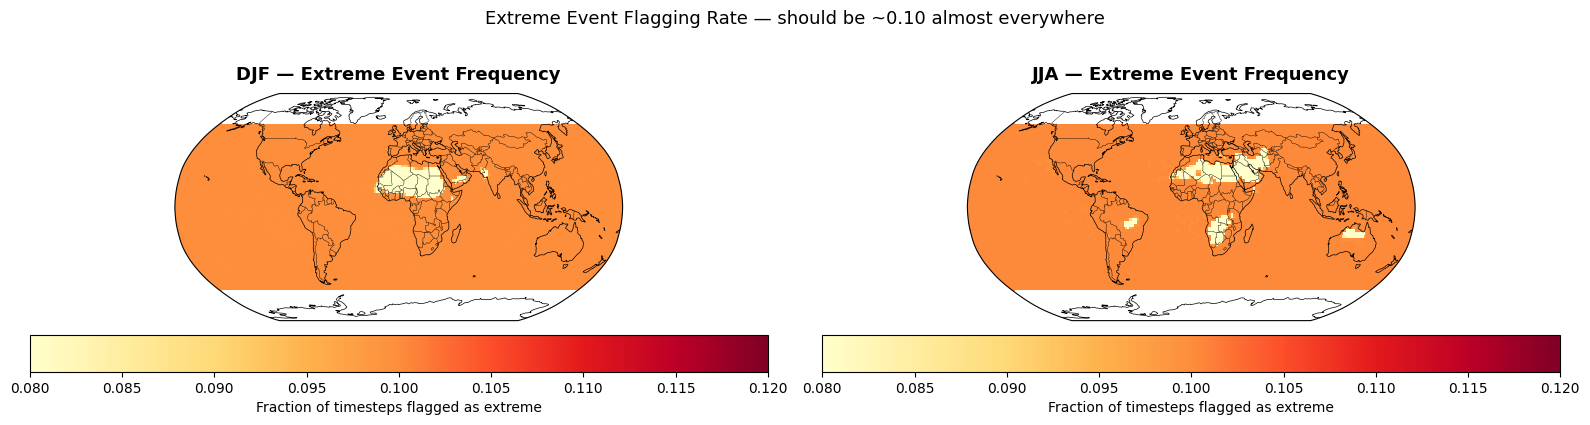

Figure saved → figures/extreme_event_frequency.png

Known deviations:
  Below 0.10 — hyperarid zones (Sahara, Arabian Peninsula)
               where p90 = 0 and strict > operator suppresses rate
  Above 0.10 — Sahel boundary zones with discrete precipitation distributions
  Both are small (±0.02) and do not affect the analysis.


In [11]:
# ── Visualize extreme event frequency maps ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4),
                         subplot_kw={'projection': ccrs.Robinson()})

for ax, data, title in zip(axes,
                           [extreme_DJF, extreme_JJA],
                           ['DJF — Extreme Event Frequency',
                            'JJA — Extreme Event Frequency']):
    freq_map = np.mean(data, axis=0)

    ax.set_global()
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3)

    im = ax.pcolormesh(lon, lat, freq_map,
                       transform=ccrs.PlateCarree(),
                       cmap='YlOrRd', shading='auto',
                       vmin=0.08, vmax=0.12)

    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    plt.colorbar(im, ax=ax, orientation='horizontal',
                 pad=0.05, label='Fraction of timesteps flagged as extreme')

plt.suptitle('Extreme Event Flagging Rate — should be ~0.10 almost everywhere',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_OUT, 'extreme_event_frequency.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → figures/extreme_event_frequency.png')
print()
print('Known deviations:')
print('  Below 0.10 — hyperarid zones (Sahara, Arabian Peninsula)')
print('               where p90 = 0 and strict > operator suppresses rate')
print('  Above 0.10 — Sahel boundary zones with discrete precipitation distributions')
print('  Both are small (±0.02) and do not affect the analysis.')

## 7. Directional Event Synchronization (GPU)

### What is Event Synchronization?

Event Synchronization (Quiroga et al. 2002) measures how often extreme events
at one location **precede** extreme events at another location within a dynamic
time window. It was adapted for climate network analysis by Malik et al. (2012)
and Boers et al. (2014) and is the de facto standard for extreme precipitation
teleconnection networks.

### The dynamic lag window

For two event series A = {a₁, a₂, ...} and B = {b₁, b₂, ...}, the dynamic
lag window for event pair (aₖ, bₗ) is:

    τ(aₖ, bₗ) = min(aₖ₊₁−aₖ, aₖ−aₖ₋₁, bₗ₊₁−bₗ, bₗ−bₗ₋₁) / 2

This window **adapts to local event density** — when events are frequent
the window is small (preventing spurious coincidences), when events are
rare the window expands (capturing slow-propagating signals).

### Directional co-occurrence counts

An event in B is **triggered by** a preceding event in A if:

    0 < bₗ − aₖ ≤ τ(aₖ, bₗ)

    c(B|A) = Σₖₗ [ 0 < bₗ − aₖ ≤ τ(aₖ, bₗ) ]   ← B follows A
    c(A|B) = Σₖₗ [ 0 < aₖ − bₗ ≤ τ(aₖ, bₗ) ]   ← A follows B

### Normalised directional ES scores

Normalised by the geometric mean of event counts to ensure comparability
across pairs with different event frequencies:

    q(A→B) = c(B|A) / √(n_A × n_B)    ← A drives B
    q(B→A) = c(A|B) / √(n_A × n_B)    ← B drives A

Scores range from 0 to 1. The resulting network is **directed**:
- **Out-degree** of node i = locations i significantly drives
- **In-degree** of node i = locations that significantly drive i

### GPU implementation strategy

The ES computation for each pair reduces to:
1. Compute pairwise time difference matrix: `diff[k,l] = b[l] - a[k]`
2. Compute dynamic window matrix: `tau[k,l] = min(tau_a[k], tau_b[l])`
3. Count directional co-occurrences: boolean masking + sum

These are pure array operations that map directly to GPU parallelism.
Both directions are filled simultaneously from one matrix operation,
halving the effective computation. Nodes with fewer than 5 events
(primarily arid regions) are skipped early.

### Significance thresholding

Rather than an arbitrary score cutoff, significance is determined by
comparing against a **surrogate null distribution** (Section 8):
1. Randomly shuffle event times for each node 1000 times
2. Compute ES scores between shuffled series
3. 95th percentile of null distribution becomes the edge threshold
4. Only edges exceeding this threshold enter the final network

In [12]:
def compute_es_matrix_gpu(event_series, min_events=5, batch_size=100):
    """
    Compute the full directional ES score matrix using GPU acceleration
    with true tensor batching — processes batch_size source nodes
    simultaneously against all targets in one GPU operation.

    The key optimisation over the naive approach: for a batch of source
    nodes, we construct a 3D difference tensor:

        diff[b, k, l] = events_j[l] - events_i_batch[b, k]

    and compute all directional counts in one vectorised operation,
    eliminating the inner Python loop over target nodes entirely.

    Parameters
    ----------
    event_series : np.ndarray, shape (n_time, n_nodes), uint8
    min_events   : int — skip nodes with fewer events (arid regions)
    batch_size   : int — source nodes processed per GPU kernel call

    Returns
    -------
    es_matrix : np.ndarray, shape (n_nodes, n_nodes), float32 (CPU)
    """
    n_time, n_nodes = event_series.shape

    # ── Precompute event times and tau arrays on CPU ───────────────────────────
    events_list  = [np.where(event_series[:, i] > 0)[0]
                    for i in range(n_nodes)]
    event_counts = np.array([len(e) for e in events_list], dtype=np.int32)
    max_events   = int(event_counts.max())

    # Flag valid nodes
    valid       = event_counts >= min_events
    n_valid     = valid.sum()
    print(f'Valid nodes (≥ {min_events} events) : {n_valid:,} / {n_nodes:,}')
    print(f'Skipped (arid/sparse)              : {n_nodes - n_valid:,}')
    print(f'Max events per node                : {max_events}')
    print(f'Batch size                         : {batch_size}')
    print()

    SENTINEL = float(1e9)

    # Pad all event arrays to max_events — use large sentinel for padding
    # so padded positions never satisfy the 0 < diff <= tau condition
    events_np = np.full((n_nodes, max_events), SENTINEL, dtype=np.float32)
    tau_np    = np.full((n_nodes, max_events), np.inf,   dtype=np.float32)

    def tau_half(events):
        n = len(events)
        if n == 1:
            return np.array([np.inf])
        diffs    = np.diff(events).astype(float)
        forward  = np.append(diffs, np.inf)
        backward = np.append(np.inf, diffs)
        return np.minimum(forward, backward) / 2.0

    for i, e in enumerate(events_list):
        n = len(e)
        if n == 0:
            continue
        events_np[i, :n] = e.astype(np.float32)
        tau_np[i,    :n] = tau_half(e).astype(np.float32)

    # Transfer padded arrays to GPU once — avoids repeated transfers
    events_gpu = cp.array(events_np)   # (n_nodes, max_events)
    tau_gpu    = cp.array(tau_np)      # (n_nodes, max_events)
    counts_gpu = cp.array(event_counts, dtype=cp.float32)

    # Allocate ES matrix on GPU
    es_gpu = cp.zeros((n_nodes, n_nodes), dtype=cp.float32)

    valid_indices = np.where(valid)[0]
    n_batches     = int(np.ceil(len(valid_indices) / batch_size))

    pbar = tqdm(
        range(n_batches),
        desc='ES matrix (GPU batched)',
        bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} batches '
                   '[{elapsed}<{remaining}, {rate_fmt}]'
    )

    for batch_idx in pbar:
        # ── Select source batch ────────────────────────────────────────────────
        batch_start  = batch_idx * batch_size
        batch_end    = min(batch_start + batch_size, len(valid_indices))
        batch_i      = valid_indices[batch_start:batch_end]  # source node indices
        bs           = len(batch_i)

        # Source events and tau for this batch: (bs, max_events)
        src_events = events_gpu[batch_i]    # (bs, max_events)
        src_tau    = tau_gpu[batch_i]       # (bs, max_events)
        src_counts = counts_gpu[batch_i]    # (bs,)

        # ── For each source in batch, compute against all valid targets j > i ──
        # We still loop over sources within the batch but the inner target
        # computation is fully vectorised across all j simultaneously

        for bi in range(bs):
            i  = int(batch_i[bi])
            ni = int(event_counts[i])
            if ni == 0:
                continue

            # Source events and tau: (ni,)
            ei     = src_events[bi, :ni]    # (ni,)
            tau_i  = src_tau[bi,    :ni]    # (ni,)

            # All valid target indices j > i
            targets = valid_indices[valid_indices > i]
            if len(targets) == 0:
                continue

            # Target events: (n_targets, max_events)
            tgt_events = events_gpu[targets]   # (n_targets, max_events)
            tgt_tau    = tau_gpu[targets]      # (n_targets, max_events)
            tgt_counts = counts_gpu[targets]   # (n_targets,)

            # ── 3D difference tensor ───────────────────────────────────────────
            # diff[t, k, l] = tgt_events[t, l] - ei[k]
            # Shape: (n_targets, ni, max_events)
            diff = (tgt_events[:, cp.newaxis, :] -
                    ei[cp.newaxis, :, cp.newaxis])

            # Dynamic window: min(tau_i[k], tgt_tau[t, l])
            # Shape: (n_targets, ni, max_events)
            tau_mat = cp.minimum(
                tau_i[cp.newaxis, :, cp.newaxis],
                tgt_tau[:, cp.newaxis, :]
            )

            # Directional counts — sum over k (source events) and l (target events)
            # c(j|i)[t] = sum over valid (k,l) where 0 < diff[t,k,l] <= tau[t,k,l]
            valid_fwd = (diff > 0) & (diff <= tau_mat)  # (n_targets, ni, max_ev)
            valid_bwd = (-diff > 0) & (-diff <= tau_mat)

            c_ji = valid_fwd.sum(axis=(1, 2)).astype(cp.float32)  # (n_targets,)
            c_ij = valid_bwd.sum(axis=(1, 2)).astype(cp.float32)  # (n_targets,)

            # Normalise
            norm = cp.sqrt(cp.float32(ni) * tgt_counts)           # (n_targets,)

            q_ij = c_ji / norm   # i → targets
            q_ji = c_ij / norm   # targets → i

            # Fill both directions
            es_gpu[i, targets]  = q_ij
            es_gpu[targets, i]  = q_ji

        # Progress update
        if batch_idx % 5 == 0:
            n_nonzero = int(cp.sum(es_gpu > 0))
            mem_free  = cp.cuda.Device().mem_info[0] / 1e9
            pbar.set_postfix({
                'non_zero': f'{n_nonzero:,}',
                'gpu_free_GB': f'{mem_free:.1f}'
            })

    cp.fill_diagonal(es_gpu, 0.0)

    # Transfer back to CPU
    es_matrix = cp.asnumpy(es_gpu)
    del es_gpu, events_gpu, tau_gpu, counts_gpu
    cp.get_default_memory_pool().free_all_blocks()

    return es_matrix

print('GPU-batched ES matrix function defined.')
print()
print('Key optimisation: 3D diff tensor eliminates inner target loop.')
print('All valid target nodes processed simultaneously per source node.')
print()
print('Expected runtime on A100:')
print('  DJF : 5–15 minutes')
print('  JJA : 5–15 minutes')
print('  Total: ~10–30 minutes')
print()
print('NOTE: Next cells will compute the ES matrices.')
print('      Do not interrupt — saved to Drive immediately after.')

GPU-batched ES matrix function defined.

Key optimisation: 3D diff tensor eliminates inner target loop.
All valid target nodes processed simultaneously per source node.

Expected runtime on A100:
  DJF : 5–15 minutes
  JJA : 5–15 minutes
  Total: ~10–30 minutes

NOTE: Next cells will compute the ES matrices.
      Do not interrupt — saved to Drive immediately after.


In [14]:
es_DJF_path = os.path.join(DATA_OUT, 'es_DJF.npy')

if os.path.exists(es_DJF_path):
    print('es_DJF.npy found on Drive — loading existing file...')
    es_DJF = np.load(es_DJF_path)
    print(f'Loaded. Shape: {es_DJF.shape}  |  Memory: {es_DJF.nbytes/1e6:.1f} MB')
    print(f'Non-zero pairs : {(es_DJF > 0).sum():,}')
    print(f'Mean score (>0): {es_DJF[es_DJF > 0].mean():.4f}')
    print(f'Max score      : {es_DJF.max():.4f}')
else:
    print('es_DJF.npy not found — computing from scratch...')
    print(f'Nodes: {n_nodes:,}  |  Max directed pairs: {n_nodes*(n_nodes-1):,}')
    print()
    es_DJF = compute_es_matrix_gpu(ex_DJF_flat)
    print(f'\nDJF done.')
    print(f'Shape          : {es_DJF.shape}')
    print(f'Memory         : {es_DJF.nbytes/1e6:.1f} MB')
    print(f'Non-zero pairs : {(es_DJF > 0).sum():,}')
    print(f'Mean score (>0): {es_DJF[es_DJF > 0].mean():.4f}')
    print(f'Max score      : {es_DJF.max():.4f}')
    np.save(es_DJF_path, es_DJF)
    print(f'\nSaved → outputs/es_DJF.npy')

es_DJF.npy found on Drive — loading existing file...
Loaded. Shape: (10800, 10800)  |  Memory: 466.6 MB
Non-zero pairs : 116,383,839
Mean score (>0): 0.0669
Max score      : 0.3586


In [15]:
es_JJA_path = os.path.join(DATA_OUT, 'es_JJA.npy')

if os.path.exists(es_JJA_path):
    print('es_JJA.npy found on Drive — loading existing file...')
    es_JJA = np.load(es_JJA_path)
    print(f'Loaded. Shape: {es_JJA.shape}  |  Memory: {es_JJA.nbytes/1e6:.1f} MB')
    print(f'Non-zero pairs : {(es_JJA > 0).sum():,}')
    print(f'Mean score (>0): {es_JJA[es_JJA > 0].mean():.4f}')
    print(f'Max score      : {es_JJA.max():.4f}')
else:
    print('es_JJA.npy not found — computing from scratch...')
    print(f'Nodes: {n_nodes:,}  |  Max directed pairs: {n_nodes*(n_nodes-1):,}')
    print()
    es_JJA = compute_es_matrix_gpu(ex_JJA_flat)
    print(f'\nJJA done.')
    print(f'Shape          : {es_JJA.shape}')
    print(f'Memory         : {es_JJA.nbytes/1e6:.1f} MB')
    print(f'Non-zero pairs : {(es_JJA > 0).sum():,}')
    print(f'Mean score (>0): {es_JJA[es_JJA > 0].mean():.4f}')
    print(f'Max score      : {es_JJA.max():.4f}')
    np.save(es_JJA_path, es_JJA)
    print(f'\nSaved → outputs/es_JJA.npy')

es_JJA.npy found on Drive — loading existing file...
Loaded. Shape: (10800, 10800)  |  Memory: 466.6 MB
Non-zero pairs : 116,450,326
Mean score (>0): 0.0713
Max score      : 0.4046


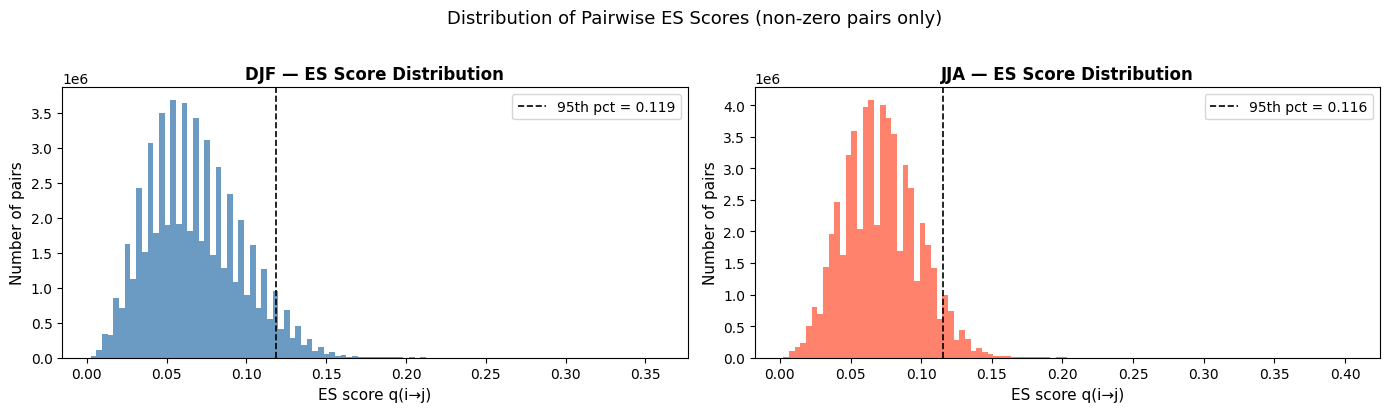

Figure saved → figures/es_score_distributions.png


In [16]:
# ── Visualize ES score distributions ──────────────────────────────────────────
# Most pairs score near 0 — genuine teleconnections form a sparse tail.
# The dashed line marks the 95th percentile of non-zero scores.
# The final significance threshold (from surrogates) is computed in Section 8.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, es, season, color in zip(axes,
                                  [es_DJF, es_JJA],
                                  ['DJF', 'JJA'],
                                  ['steelblue', 'tomato']):
    idx     = np.triu_indices(n_nodes, k=1)
    vals    = es[idx]
    nonzero = vals[vals > 0]

    ax.hist(nonzero, bins=100, color=color, alpha=0.8, edgecolor='none')
    p95 = np.percentile(nonzero, 95) if len(nonzero) > 0 else 0
    ax.axvline(p95, color='black', linewidth=1.2, linestyle='--',
               label=f'95th pct = {p95:.3f}')
    ax.set_xlabel('ES score q(i→j)', fontsize=11)
    ax.set_ylabel('Number of pairs', fontsize=11)
    ax.set_title(f'{season} — ES Score Distribution',
                 fontsize=12, fontweight='bold')
    ax.legend()

plt.suptitle('Distribution of Pairwise ES Scores (non-zero pairs only)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_OUT, 'es_score_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → figures/es_score_distributions.png')

## 8. Surrogate-Based Significance Thresholding

### Why surrogate testing?

An ES score by itself does not tell us whether a directional relationship
is statistically significant — we need to compare it against what would
be expected if the two series were unrelated. We generate a **null
distribution** by computing ES scores between randomly shuffled event
series, preserving the number of events but destroying any temporal
structure.

### Procedure

1. For each node, randomly shuffle its event times **1000 times**,
   preserving the total event count
2. For each shuffle, compute ES scores between a random sample of
   node pairs (computing all pairs would take too long)
3. Pool all surrogate ES scores to build the null distribution
4. The **95th percentile** of the null distribution becomes the
   significance threshold — edges below this value could plausibly
   arise by chance

### Why 95th percentile?

The 95th percentile corresponds to a significance level of α = 0.05 —
the standard threshold in network science. Only edges where the observed
ES score exceeds 95% of what random temporal shuffling produces are
retained in the final network.

### Implementation note

Rather than running 1000 surrogates for all ~58 million pairs (which
would take days), we use a **random sample of 10,000 node pairs** per
surrogate iteration. This gives ~10 million surrogate scores — more than
sufficient to accurately estimate the 95th percentile of the null
distribution while keeping computation tractable.

In [17]:
def compute_surrogate_threshold_gpu(event_series, n_surrogates=1000,
                                     n_sample_pairs=10000, alpha=0.05,
                                     min_events=5, batch_pairs=500):
    """
    GPU-accelerated surrogate-based significance threshold for ES scores.

    Rather than computing surrogates one pair at a time on CPU, we:
    1. Sample n_sample_pairs node pairs per surrogate iteration
    2. Generate all surrogate event series on GPU using random sampling
    3. Compute ES scores for all sampled pairs simultaneously in batches
    4. Pool all surrogate scores to build the null distribution

    Parameters
    ----------
    event_series   : np.ndarray, shape (n_time, n_nodes), uint8
    n_surrogates   : int — surrogate iterations (default 1000)
    n_sample_pairs : int — pairs sampled per iteration (default 10000)
    alpha          : float — significance level (default 0.05)
    min_events     : int — minimum events for valid node
    batch_pairs    : int — pairs processed per GPU batch

    Returns
    -------
    threshold : float — ES significance threshold at alpha level
    null_dist : np.ndarray — full surrogate null distribution
    """
    n_time, n_nodes = event_series.shape

    # Pre-extract event times and counts
    events_list  = [np.where(event_series[:, i] > 0)[0]
                    for i in range(n_nodes)]
    event_counts = np.array([len(e) for e in events_list], dtype=np.int32)
    valid_idx    = np.where(event_counts >= min_events)[0]
    max_events   = int(event_counts[valid_idx].max())

    print(f'Valid nodes      : {len(valid_idx):,}')
    print(f'Max events/node  : {max_events}')
    print(f'Surrogates       : {n_surrogates}')
    print(f'Pairs/surrogate  : {n_sample_pairs:,}')
    print(f'Total null scores: {n_surrogates * n_sample_pairs:,}')
    print()

    null_scores = []

    pbar = tqdm(
        range(n_surrogates),
        desc='Surrogate iterations (GPU)',
        bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} '
                   '[{elapsed}<{remaining}, {rate_fmt}]'
    )

    for surr_idx in pbar:

        # ── Sample random node pairs ───────────────────────────────────────────
        pair_i = cp.array(
            np.random.choice(valid_idx, size=n_sample_pairs, replace=True)
        )
        pair_j = cp.array(
            np.random.choice(valid_idx, size=n_sample_pairs, replace=True)
        )
        # Remove self-pairs
        mask   = pair_i != pair_j
        pair_i = pair_i[mask]
        pair_j = pair_j[mask]
        n_pairs = len(pair_i)

        # ── Generate surrogate event times on GPU ─────────────────────────────
        # For each node in the pair, shuffle event times by randomly
        # sampling n_events positions from [0, n_time) without replacement.
        # We generate surrogates for all pairs simultaneously.

        # Get event counts for sampled nodes
        counts_i = cp.array(event_counts[cp.asnumpy(pair_i)])  # (n_pairs,)
        counts_j = cp.array(event_counts[cp.asnumpy(pair_j)])  # (n_pairs,)

        # Process in batches to avoid GPU memory overflow
        surr_scores = []

        for bp_start in range(0, n_pairs, batch_pairs):
            bp_end = min(bp_start + batch_pairs, n_pairs)
            bs     = bp_end - bp_start

            ci = cp.asnumpy(counts_i[bp_start:bp_end])  # (bs,)
            cj = cp.asnumpy(counts_j[bp_start:bp_end])  # (bs,)

            # Generate surrogate events for this batch on CPU
            # (random.choice without replacement — hard to vectorise on GPU)
            max_ci = int(ci.max())
            max_cj = int(cj.max())

            surr_i = np.full((bs, max_ci), float(1e9), dtype=np.float32)
            surr_j = np.full((bs, max_cj), float(1e9), dtype=np.float32)
            tau_si = np.full((bs, max_ci), np.inf,     dtype=np.float32)
            tau_sj = np.full((bs, max_cj), np.inf,     dtype=np.float32)

            def tau_half_np(events):
                n = len(events)
                if n == 1:
                    return np.array([np.inf])
                diffs    = np.diff(events).astype(float)
                forward  = np.append(diffs, np.inf)
                backward = np.append(np.inf, diffs)
                return np.minimum(forward, backward) / 2.0

            for b in range(bs):
                # Surrogate for node i — random event times
                si = np.sort(np.random.choice(
                    n_time, int(ci[b]), replace=False
                )).astype(np.float32)
                surr_i[b, :len(si)] = si
                tau_si[b, :len(si)] = tau_half_np(si).astype(np.float32)

                # Surrogate for node j
                sj = np.sort(np.random.choice(
                    n_time, int(cj[b]), replace=False
                )).astype(np.float32)
                surr_j[b, :len(sj)] = sj
                tau_sj[b, :len(sj)] = tau_half_np(sj).astype(np.float32)

            # Transfer to GPU
            surr_i_gpu = cp.array(surr_i)   # (bs, max_ci)
            surr_j_gpu = cp.array(surr_j)   # (bs, max_cj)
            tau_si_gpu = cp.array(tau_si)   # (bs, max_ci)
            tau_sj_gpu = cp.array(tau_sj)   # (bs, max_cj)
            ci_gpu     = cp.array(ci, dtype=cp.float32)
            cj_gpu     = cp.array(cj, dtype=cp.float32)

            # ── Batch ES computation on GPU ────────────────────────────────────
            # diff[b, k, l] = surr_j[b, l] - surr_i[b, k]
            # Shape: (bs, max_ci, max_cj)
            diff = (surr_j_gpu[:, cp.newaxis, :] -
                    surr_i_gpu[:, :, cp.newaxis])

            tau_mat = cp.minimum(
                tau_si_gpu[:, :, cp.newaxis],
                tau_sj_gpu[:, cp.newaxis, :]
            )

            # Count forward co-occurrences: 0 < diff <= tau
            c_ji = (((diff > 0) & (diff <= tau_mat))
                    .sum(axis=(1, 2))
                    .astype(cp.float32))

            norm       = cp.sqrt(ci_gpu * cj_gpu)
            q_ij_batch = c_ji / norm

            surr_scores.append(cp.asnumpy(q_ij_batch))

            # Clean up GPU memory
            del surr_i_gpu, surr_j_gpu, tau_si_gpu, tau_sj_gpu
            del diff, tau_mat, c_ji, q_ij_batch
            cp.get_default_memory_pool().free_all_blocks()

        null_scores.extend(np.concatenate(surr_scores).tolist())

        # Progress update
        if surr_idx % 50 == 0 and len(null_scores) > 0:
            current_threshold = np.percentile(null_scores,
                                              (1 - alpha) * 100)
            pbar.set_postfix({
                'n_scores'    : f'{len(null_scores):,}',
                'running_thr' : f'{current_threshold:.4f}'
            })

    null_dist = np.array(null_scores, dtype=np.float32)
    threshold = float(np.percentile(null_dist, (1 - alpha) * 100))

    print(f'\nNull distribution:')
    print(f'  Scores collected : {len(null_dist):,}')
    print(f'  Mean             : {null_dist.mean():.4f}')
    print(f'  Std              : {null_dist.std():.4f}')
    print(f'  Max              : {null_dist.max():.4f}')
    print(f'  Threshold (α={alpha}) : {threshold:.4f}')

    return threshold, null_dist

print('GPU-accelerated surrogate threshold function defined.')

GPU-accelerated surrogate threshold function defined.


In [18]:
thresh_DJF_path = os.path.join(DATA_OUT, 'es_threshold_DJF.npy')

if os.path.exists(thresh_DJF_path):
    print('es_threshold_DJF.npy found on Drive — loading existing file...')
    thresh_DJF = float(np.load(thresh_DJF_path)[0])
    print(f'Loaded threshold : {thresh_DJF:.4f}')
    null_DJF = None  # not needed if threshold already computed
else:
    print('es_threshold_DJF.npy not found — computing surrogates...')
    print('(1000 surrogates × 10,000 sampled pairs)')
    print()
    thresh_DJF, null_DJF = compute_surrogate_threshold_gpu(
        event_series   = ex_DJF_flat,
        n_surrogates   = 1000,
        n_sample_pairs = 10000,
        alpha          = 0.05
    )
    np.save(thresh_DJF_path, np.array([thresh_DJF]))
    print(f'\nSaved → outputs/es_threshold_DJF.npy')

es_threshold_DJF.npy found on Drive — loading existing file...
Loaded threshold : 0.1401


In [24]:
thresh_JJA_path = os.path.join(DATA_OUT, 'es_threshold_JJA.npy')

if os.path.exists(thresh_JJA_path):
    print('es_threshold_JJA.npy found on Drive — loading existing file...')
    thresh_JJA = float(np.load(thresh_JJA_path)[0])
    print(f'Loaded threshold : {thresh_JJA:.4f}')
    null_JJA = None
else:
    print('es_threshold_JJA.npy not found — computing surrogates...')
    print()
    thresh_JJA, null_JJA = compute_surrogate_threshold_gpu(
        event_series   = ex_JJA_flat,
        n_surrogates   = 1000,
        n_sample_pairs = 10000,
        alpha          = 0.05
    )
    np.save(thresh_JJA_path, np.array([thresh_JJA]))
    print(f'\nSaved → outputs/es_threshold_JJA.npy')

es_threshold_JJA.npy found on Drive — loading existing file...
Loaded threshold : 0.1415


In [33]:
# ── Visualize null distributions and apply thresholds ─────────────────────────
# If thresholds were loaded from file (not freshly computed),
# null distributions are not available — we skip the plot and
# print the loaded threshold values instead.

if null_DJF is not None and null_JJA is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for ax, null, thresh, season, color in zip(
            axes,
            [null_DJF, null_JJA],
            [thresh_DJF, thresh_JJA],
            ['DJF', 'JJA'],
            ['steelblue', 'tomato']):

        ax.hist(null, bins=100, color=color, alpha=0.8, edgecolor='none',
                label='Null distribution (surrogates)')
        ax.axvline(thresh, color='black', linewidth=1.5, linestyle='--',
                   label=f'Threshold (α=0.05) = {thresh:.4f}')
        ax.set_xlabel('Surrogate ES score', fontsize=11)
        ax.set_ylabel('Count', fontsize=11)
        ax.set_title(f'{season} — Surrogate Null Distribution',
                     fontsize=12, fontweight='bold')
        ax.legend()

    plt.suptitle('Surrogate-Based Significance Thresholds for ES Scores',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_OUT, 'surrogate_null_distributions.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print('Figure saved → figures/surrogate_null_distributions.png')

else:
    print('Null distributions not available — thresholds loaded from Drive.')
    print()
    print(f'DJF threshold (α=0.05) : {thresh_DJF:.4f}')
    print(f'JJA threshold (α=0.05) : {thresh_JJA:.4f}')
    print()
    print('To regenerate the null distribution plot, delete the threshold')
    print('files from Drive and rerun the two cells above')

print()

# ── Apply thresholds and report surviving edges ────────────────────────────────
adj_DJF = (es_DJF > thresh_DJF).astype(np.uint8)
adj_JJA = (es_JJA > thresh_JJA).astype(np.uint8)
np.fill_diagonal(adj_DJF, 0)
np.fill_diagonal(adj_JJA, 0)

n_edges_DJF = int(adj_DJF.sum())
n_edges_JJA = int(adj_JJA.sum())

print(f'DJF threshold              : {thresh_DJF:.4f}')
print(f'JJA threshold              : {thresh_JJA:.4f}')
print()
print(f'DJF — surviving directed edges : {n_edges_DJF:,}')
print(f'JJA — surviving directed edges : {n_edges_JJA:,}')
print()
print(f'DJF link density : {n_edges_DJF / (n_nodes*(n_nodes-1)):.5f}')
print(f'JJA link density : {n_edges_JJA / (n_nodes*(n_nodes-1)):.5f}')
print()

# Preliminary H1 check — DJF should have more edges than JJA
if n_edges_DJF > n_edges_JJA:
    diff_pct = (n_edges_DJF - n_edges_JJA) / n_edges_JJA * 100
    print(f'DJF > JJA by {n_edges_DJF - n_edges_JJA:,} edges ({diff_pct:.1f}%)')
    print('Directionally consistent with H1.')
else:
    diff_pct = (n_edges_JJA - n_edges_DJF) / n_edges_DJF * 100
    print(f'JJA > DJF by {n_edges_JJA - n_edges_DJF:,} edges ({diff_pct:.1f}%)')
    print('Directionally inconsistent with H1 — investigate further in 03_analysis.ipynb.')

Null distributions not available — thresholds loaded from Drive.

DJF threshold (α=0.05) : 0.1401
JJA threshold (α=0.05) : 0.1415

To regenerate the null distribution plot, delete the threshold
files from Drive and rerun the two cells above

DJF threshold              : 0.1401
JJA threshold              : 0.1415

DJF — surviving directed edges : 1,145,959
JJA — surviving directed edges : 593,363

DJF link density : 0.00983
JJA link density : 0.00509

DJF > JJA by 552,596 edges (93.1%)
Directionally consistent with H1.


## 9. NetworkX Graph Construction

We build **directed** NetworkX graph objects from the thresholded ES matrices.
NetworkX's `DiGraph` preserves edge directionality — essential for computing
in-degree and out-degree separately.

### Node attributes

Each node receives:
- `lat` — latitude of grid cell centre
- `lon` — longitude of grid cell centre

### Edge attributes

Each directed edge (i→j) receives:
- `weight` — ES score q(i→j)

### Node indexing

Nodes are indexed 0 to (n_nodes−1). Geographic coordinates recovered as:

    lat_idx = node_idx // n_lon
    lon_idx = node_idx  % n_lon

This works because NumPy flattens in row-major order — longitude is the
fast-moving dimension.

In [26]:
def build_digraph(adj, es_matrix, lat, lon, season_label):
    """
    Build a directed NetworkX graph from a thresholded adjacency matrix.

    Parameters
    ----------
    adj          : np.ndarray, shape (n_nodes, n_nodes), uint8
                   Thresholded binary adjacency matrix
    es_matrix    : np.ndarray, shape (n_nodes, n_nodes), float32
                   ES score matrix for edge weights
    lat          : np.ndarray — latitude values
    lon          : np.ndarray — longitude values
    season_label : str

    Returns
    -------
    G : nx.DiGraph
    """
    n_lon   = len(lon)
    n_nodes = len(lat) * len(lon)

    G = nx.DiGraph()
    G.graph['season'] = season_label

    # Add all nodes with geographic attributes
    for node_idx in range(n_nodes):
        lat_idx = node_idx // n_lon
        lon_idx = node_idx  % n_lon
        G.add_node(node_idx,
                   lat=float(lat[lat_idx]),
                   lon=float(lon[lon_idx]))

    # Add directed edges with ES score as weight
    rows, cols = np.where(adj > 0)
    for i, j in zip(rows, cols):
        G.add_edge(int(i), int(j), weight=float(es_matrix[i, j]))

    return G

print('Building directed graphs...')
G_DJF = build_digraph(adj_DJF, es_DJF, lat, lon, 'DJF')
G_JJA = build_digraph(adj_JJA, es_JJA, lat, lon, 'JJA')

print(f'DJF — nodes: {G_DJF.number_of_nodes():,}  |  '
      f'directed edges: {G_DJF.number_of_edges():,}')
print(f'JJA — nodes: {G_JJA.number_of_nodes():,}  |  '
      f'directed edges: {G_JJA.number_of_edges():,}')

Building directed graphs...
DJF — nodes: 10,800  |  directed edges: 1,145,959
JJA — nodes: 10,800  |  directed edges: 593,363


In [27]:
# ── Basic network statistics ───────────────────────────────────────────────────
# In a directed network, each node has both in-degree and out-degree.
# Out-degree = how many locations this node drives (teleconnection source)
# In-degree  = how many locations drive this node (teleconnection receiver)

print('Network statistics:')
print()

for G, season in [(G_DJF, 'DJF'), (G_JJA, 'JJA')]:
    out_degrees = [d for _, d in G.out_degree()]
    in_degrees  = [d for _, d in G.in_degree()]
    density     = nx.density(G)

    print(f'{season}')
    print(f'  Nodes              : {G.number_of_nodes():,}')
    print(f'  Directed edges     : {G.number_of_edges():,}')
    print(f'  Mean out-degree    : {np.mean(out_degrees):.2f}')
    print(f'  Mean in-degree     : {np.mean(in_degrees):.2f}')
    print(f'  Max out-degree     : {max(out_degrees):,}')
    print(f'  Max in-degree      : {max(in_degrees):,}')
    print(f'  Link density       : {density:.5f}')
    print()

Network statistics:

DJF
  Nodes              : 10,800
  Directed edges     : 1,145,959
  Mean out-degree    : 106.11
  Mean in-degree     : 106.11
  Max out-degree     : 1,278
  Max in-degree      : 1,292
  Link density       : 0.00983

JJA
  Nodes              : 10,800
  Directed edges     : 593,363
  Mean out-degree    : 54.94
  Mean in-degree     : 54.94
  Max out-degree     : 765
  Max in-degree      : 745
  Link density       : 0.00509



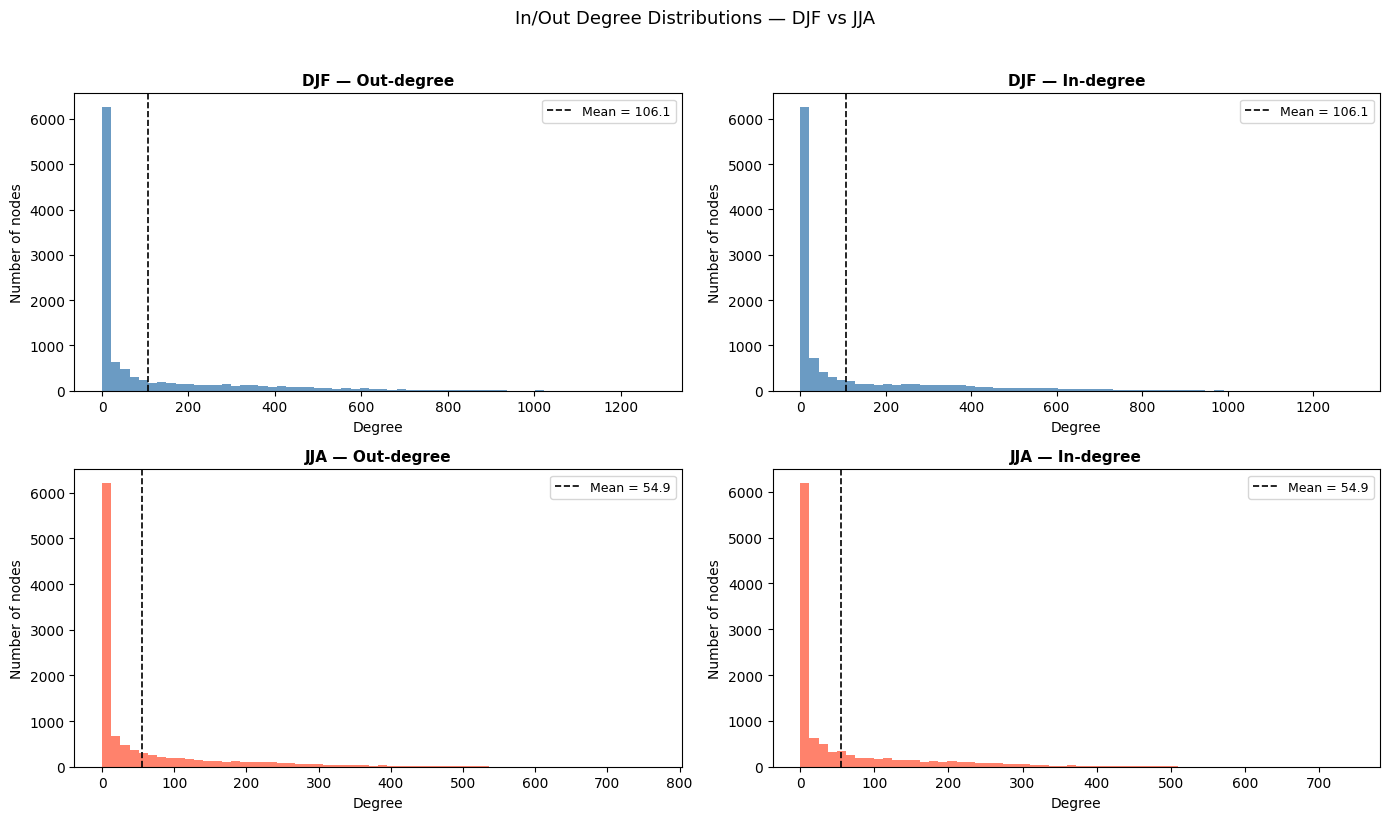

Figure saved → figures/degree_distributions.png


In [28]:
# ── Degree distribution plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

configs = [
    (axes[0,0], [d for _,d in G_DJF.out_degree()], 'DJF — Out-degree', 'steelblue'),
    (axes[0,1], [d for _,d in G_DJF.in_degree()],  'DJF — In-degree',  'steelblue'),
    (axes[1,0], [d for _,d in G_JJA.out_degree()], 'JJA — Out-degree', 'tomato'),
    (axes[1,1], [d for _,d in G_JJA.in_degree()],  'JJA — In-degree',  'tomato'),
]

for ax, degrees, title, color in configs:
    ax.hist(degrees, bins=60, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(np.mean(degrees), color='black', linewidth=1.2,
               linestyle='--', label=f'Mean = {np.mean(degrees):.1f}')
    ax.set_xlabel('Degree', fontsize=10)
    ax.set_ylabel('Number of nodes', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('In/Out Degree Distributions — DJF vs JJA', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_OUT, 'degree_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → figures/degree_distributions.png')

## 10. Export & Download

We export all outputs needed for local analysis and visualization:

- **GEXF files** — Gephi-compatible directed graph format with node
  lat/lon attributes and ES edge weights
- **Node CSV files** — node attribute tables including both in-degree
  and out-degree for each season
- **Download** — all key files downloaded to local machine for
  notebooks 03 and 04

### Why GEXF for Gephi?

GEXF (Graph Exchange XML Format) is Gephi's native format. It preserves
directed edges, node attributes, and edge weights. When opened in Gephi,
nodes can be positioned geographically using lat/lon coordinates, and
edge direction can be visualized with arrows.

In [29]:
# ── Export GEXF files ─────────────────────────────────────────────────────────
nx.write_gexf(G_DJF, os.path.join(DATA_OUT, 'network_DJF.gexf'))
nx.write_gexf(G_JJA, os.path.join(DATA_OUT, 'network_JJA.gexf'))

print('GEXF files saved:')
print(f'  outputs/network_DJF.gexf')
print(f'  outputs/network_JJA.gexf')

GEXF files saved:
  outputs/network_DJF.gexf
  outputs/network_JJA.gexf


In [30]:
# ── Export node attribute tables ──────────────────────────────────────────────
# Each row is one node.
# Columns: node_id, lat, lon, out_degree, in_degree
# Used in 03_analysis.ipynb and 04_visualization.ipynb

for G, season in [(G_DJF, 'DJF'), (G_JJA, 'JJA')]:
    out_deg = dict(G.out_degree())
    in_deg  = dict(G.in_degree())

    rows = []
    for node_idx in G.nodes():
        rows.append({
            'node_id'    : node_idx,
            'lat'        : G.nodes[node_idx]['lat'],
            'lon'        : G.nodes[node_idx]['lon'],
            'out_degree' : out_deg[node_idx],
            'in_degree'  : in_deg[node_idx]
        })

    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(DATA_OUT, f'nodes_{season}.csv'), index=False)
    print(f'nodes_{season}.csv  |  shape: {df.shape}  |  '
          f'mean out-degree: {df["out_degree"].mean():.2f}  |  '
          f'mean in-degree: {df["in_degree"].mean():.2f}')

print()
print('All outputs saved to Drive.')

nodes_DJF.csv  |  shape: (10800, 5)  |  mean out-degree: 106.11  |  mean in-degree: 106.11
nodes_JJA.csv  |  shape: (10800, 5)  |  mean out-degree: 54.94  |  mean in-degree: 54.94

All outputs saved to Drive.


In [31]:
# ── Download all key outputs to local machine ─────────────────────────────────
# Run this cell after all computation is complete.
# Files will download to your browser's default download folder.
# Move them to your local TeleShift/outputs/ and TeleShift/figures/ folders.

from google.colab import files

download_files = [
    # ES matrices
    os.path.join(DATA_OUT, 'es_DJF.npy'),
    os.path.join(DATA_OUT, 'es_JJA.npy'),
    # Surrogate thresholds
    os.path.join(DATA_OUT, 'es_threshold_DJF.npy'),
    os.path.join(DATA_OUT, 'es_threshold_JJA.npy'),
    # Networks
    os.path.join(DATA_OUT, 'network_DJF.gexf'),
    os.path.join(DATA_OUT, 'network_JJA.gexf'),
    # Node tables
    os.path.join(DATA_OUT, 'nodes_DJF.csv'),
    os.path.join(DATA_OUT, 'nodes_JJA.csv'),
    # Figures
    os.path.join(FIG_OUT, 'analysis_domain.png'),
    os.path.join(FIG_OUT, 'seasonal_mean_precip.png'),
    os.path.join(FIG_OUT, 'extreme_event_frequency.png'),
    os.path.join(FIG_OUT, 'es_score_distributions.png'),
    os.path.join(FIG_OUT, 'surrogate_null_distributions.png'),
    os.path.join(FIG_OUT, 'degree_distributions.png'),
]

print('Initiating downloads...')
for f in download_files:
    if os.path.exists(f):
        files.download(f)
        print(f'  Downloaded: {os.path.basename(f)}')
    else:
        print(f'  NOT FOUND : {os.path.basename(f)}')

Initiating downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: es_DJF.npy


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  Downloaded: es_score_distributions.png
  NOT FOUND : surrogate_null_distributions.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: degree_distributions.png


## 11. Summary

This notebook constructed two directed weighted climate networks from ERA5
extreme precipitation data for the analysis domain 60°S–60°N.

### Design decisions

| Decision | Choice | Rationale |
|---|---|---|
| Runtime | Google Colab Pro A100 GPU | ES matrix computation: hours on CPU → minutes on GPU |
| Spatial resolution | 2° (coarsened from 1°) | 1° networks 99.99% dominated by local autocorrelation |
| Analysis domain | 60°S – 60°N | Polar cells produce trivially high same-day correlations |
| Event definition | Binary, local 90th percentile | Natural input for ES; 10% flagging rate ensures sufficient event density |
| Synchronization | Directional Event Synchronization | Literature standard for extreme precip networks; handles binary data, directionality, and lag |
| Threshold | Surrogate-based (α = 0.05, 1000 shuffles) | Data-driven; accounts for event density and temporal structure |
| Network type | Directed weighted DiGraph | Preserves teleconnection directionality |

### Outputs produced

| File | Description |
|---|---|
| `es_DJF.npy` | Directional ES score matrix, winter |
| `es_JJA.npy` | Directional ES score matrix, summer |
| `es_threshold_DJF.npy` | Surrogate significance threshold, winter |
| `es_threshold_JJA.npy` | Surrogate significance threshold, summer |
| `network_DJF.gexf` | Directed graph for Gephi, winter |
| `network_JJA.gexf` | Directed graph for Gephi, summer |
| `nodes_DJF.csv` | Node table (lat, lon, out/in-degree), winter |
| `nodes_JJA.csv` | Node table (lat, lon, out/in-degree), summer |

### Next step

→ `03_analysis.ipynb` — hypothesis testing, hub identification,
link distance analysis, and percolation analysis on long-range subnetworks.